# Anomalias e extremos

**Objetivo:** identificar dias excepcionalmente altos ou baixos, medir a frequencia desses eventos e inspecionar o contexto temporal em torno deles.

Nesta etapa vamos combinar duas visoes:
- **extremos brutos**, baseados no proprio nivel observado da serie;
- **anomalias ajustadas**, baseadas no desvio em relacao ao valor esperado pela tendencia + sazonalidade, quando a decomposicao estiver disponivel.

Essa combinacao e util porque, em series de saude, um valor alto pode ser apenas sazonal para o inverno, enquanto outro pode ser realmente incomum mesmo depois de controlar tendencia e calendario.

## Configurações e importações
Bibliotecas usadas e parâmetros gerais.

In [9]:

import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import median_abs_deviation
try:
    from statsmodels.tsa.seasonal import MSTL
    metodo_decomposicao = "MSTL"
except ImportError:
    from statsmodels.tsa.seasonal import STL
    metodo_decomposicao = "STL"

In [6]:
meses = {
    1: "Jan", 2: "Fev", 3: "Mar", 4: "Abr", 5: "Mai", 6: "Jun",
    7: "Jul", 8: "Ago", 9: "Set", 10: "Out", 11: "Nov", 12: "Dez"
}

dias_semana = {
    0: "Seg", 1: "Ter", 2: "Qua", 3: "Qui", 4: "Sex", 5: "Sab", 6: "Dom"
}

## Consumindo o datasets (Internações)

**Objetivo:** Consumir o dataset com as quantidades de internações por doenças respiratórias da cidade do Rio de Janeiro de 2012 até 2024

In [7]:
url_internacoes = "https://raw.githubusercontent.com/AILAB-CEFET-RJ/qualiar/refs/heads/Refactoring-And-Documentation/Data/IntermediaryData/DataSus/respiratory_hospitalization_time_series.csv"

df_internacoes = pd.read_csv(url_internacoes)

df_serie = df_internacoes.copy()

df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"], errors="coerce")

df_serie = df_serie.sort_values("data_dia").reset_index(drop=True)

## Anomalias e extremos

In [10]:
if not pd.api.types.is_datetime64_any_dtype(df_serie["data_dia"]):
    df_serie = df_serie.copy()
    df_serie["data_dia"] = pd.to_datetime(df_serie["data_dia"])

# Reorganizamos a serie diaria em frequencia regular para facilitar a deteccao de extremos.
serie_extremos = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

faltantes_extremos = int(serie_extremos.isna().sum())
if faltantes_extremos > 0:
    print(f"Foram encontrados {faltantes_extremos} dias faltantes. A serie sera interpolada para a analise de extremos.")
    serie_extremos = serie_extremos.interpolate(method="time").ffill().bfill()

df_extremos = pd.DataFrame(index=serie_extremos.index)
df_extremos["num_internacoes"] = serie_extremos
df_extremos["ano"] = df_extremos.index.year
df_extremos["mes"] = df_extremos.index.month
df_extremos["mes_nome"] = pd.Categorical(
    df_extremos["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_extremos["dia_semana_nome"] = pd.Categorical(
    pd.Index(df_extremos.index.dayofweek).map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

serie_decomp = (
    df_serie[["data_dia", "num_internacoes"]]
    .drop_duplicates(subset="data_dia")
    .sort_values("data_dia")
    .set_index("data_dia")["num_internacoes"]
    .asfreq("D")
)

# Caso haja lacunas na serie, interpolamos apenas para viabilizar a decomposicao.
faltantes_decomp = int(serie_decomp.isna().sum())
if faltantes_decomp > 0:
    print(f"Foram encontrados {faltantes_decomp} dias faltantes. A serie sera interpolada para a decomposicao.")
    serie_decomp = serie_decomp.interpolate(method="time")
else:
    print("Nenhum dia faltante foi encontrado para a decomposicao.")

print("Metodo selecionado:", metodo_decomposicao)
display(serie_decomp.head().to_frame(name="num_internacoes"))

if metodo_decomposicao == "MSTL":
    periodos_decomposicao = (7, 365)
    resultado_decomp = MSTL(
        serie_decomp,
        periods=periodos_decomposicao,
        stl_kwargs={"robust": True},
    ).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal["seasonal_7"]
    df_decomp["sazonal_365"] = resultado_decomp.seasonal["seasonal_365"]
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"] + df_decomp["sazonal_365"]
    df_decomp["residuo"] = resultado_decomp.resid
else:
    from statsmodels.tsa.seasonal import STL

    periodos_decomposicao = (7,)
    resultado_decomp = STL(serie_decomp, period=7, robust=True).fit()

    df_decomp = pd.DataFrame(index=serie_decomp.index)
    df_decomp["observado"] = resultado_decomp.observed
    df_decomp["tendencia"] = resultado_decomp.trend
    df_decomp["sazonal_7"] = resultado_decomp.seasonal
    df_decomp["sazonal_365"] = np.nan
    df_decomp["sazonal_total"] = df_decomp["sazonal_7"]
    df_decomp["residuo"] = resultado_decomp.resid

# Adicionamos chaves de calendario para resumir e comparar os componentes depois.
df_decomp["ano"] = df_decomp.index.year
df_decomp["mes"] = df_decomp.index.month
df_decomp["mes_nome"] = pd.Categorical(
    df_decomp["mes"].map(meses),
    categories=list(meses.values()),
    ordered=True,
)
df_decomp["dia_semana_num"] = df_decomp.index.dayofweek
df_decomp["dia_semana_nome"] = pd.Categorical(
    df_decomp["dia_semana_num"].map(dias_semana),
    categories=list(dias_semana.values()),
    ordered=True,
)

# Sempre que a decomposicao estiver disponivel, usamos tendencia + sazonalidade como referencia.
usa_decomposicao = "df_decomp" in globals() and {"tendencia", "sazonal_total", "residuo"}.issubset(df_decomp.columns)

if usa_decomposicao:
    componentes_extremos = df_decomp[["tendencia", "sazonal_total", "residuo"]].copy()
    componentes_extremos.index = pd.to_datetime(componentes_extremos.index)
    df_extremos = df_extremos.join(componentes_extremos, how="left")
    df_extremos["valor_esperado"] = df_extremos["tendencia"] + df_extremos["sazonal_total"]
    df_extremos["desvio_ajustado"] = df_extremos["num_internacoes"] - df_extremos["valor_esperado"]
    metodo_referencia = "Tendencia + sazonalidade da decomposicao"
else:
    df_extremos["tendencia"] = (
        df_extremos["num_internacoes"]
        .rolling(window=30, center=True, min_periods=15)
        .median()
        .bfill()
        .ffill()
    )
    df_extremos["sazonal_total"] = 0.0
    df_extremos["residuo"] = df_extremos["num_internacoes"] - df_extremos["tendencia"]
    df_extremos["valor_esperado"] = df_extremos["tendencia"]
    df_extremos["desvio_ajustado"] = df_extremos["residuo"]
    metodo_referencia = "Mediana movel de 30 dias"

# Padronizamos o desvio ajustado com z-score robusto para reduzir a sensibilidade a outliers.
centro_desvio = df_extremos["desvio_ajustado"].median()
escala_robusta = median_abs_deviation(df_extremos["desvio_ajustado"].dropna(), scale="normal")
if np.isnan(escala_robusta) or escala_robusta == 0:
    escala_robusta = df_extremos["desvio_ajustado"].std()

df_extremos["z_robusto"] = (df_extremos["desvio_ajustado"] - centro_desvio) / escala_robusta

# Combinamos quantis extremos mais conservadores com limiares robustos no desvio ajustado.
q_superior = df_extremos["num_internacoes"].quantile(0.995)
q_inferior = df_extremos["num_internacoes"].quantile(0.005)
df_extremos["pico_extremo"] = (df_extremos["num_internacoes"] >= q_superior) | (df_extremos["z_robusto"] >= 5)
df_extremos["vale_extremo"] = (df_extremos["num_internacoes"] <= q_inferior) | (df_extremos["z_robusto"] <= -5)
df_extremos["extremo"] = df_extremos["pico_extremo"] | df_extremos["vale_extremo"]

print("Referencia usada para o valor esperado:", metodo_referencia)
print(f"Limiar bruto superior (q99.5): {q_superior:.1f}")
print(f"Limiar bruto inferior (q0.5): {q_inferior:.1f}")
print(f"Centro do desvio ajustado: {centro_desvio:.2f}")
print(f"Escala robusta (MAD normalizada): {escala_robusta:.2f}")

display(df_extremos.head().round(2))

Nenhum dia faltante foi encontrado para a decomposicao.
Metodo selecionado: MSTL


,num_internacoes
data_dia,
2012-01-01,546
2012-01-02,784
2012-01-03,462
2012-01-04,448
2012-01-05,434


Referencia usada para o valor esperado: Tendencia + sazonalidade da decomposicao
Limiar bruto superior (q99.5): 1062.3
Limiar bruto inferior (q0.5): 28.6
Centro do desvio ajustado: 1.00
Escala robusta (MAD normalizada): 43.62


,num_internacoes,ano,mes,mes_nome,dia_semana_nome,tendencia,sazonal_total,residuo,valor_esperado,desvio_ajustado,z_robusto,pico_extremo,vale_extremo,extremo
data_dia,,,,,,,,,,,,,,
2012-01-01,546,2012,1,Jan,Dom,650.07,-417.61,313.54,232.46,313.54,7.17,True,False,True
2012-01-02,784,2012,1,Jan,Seg,649.78,142.17,-7.95,791.95,-7.95,-0.21,False,False,False
2012-01-03,462,2012,1,Jan,Ter,649.50,-110.76,-76.73,538.73,-76.73,-1.78,False,False,False
2012-01-04,448,2012,1,Jan,Qua,649.21,-160.60,-40.61,488.61,-40.61,-0.95,False,False,False
2012-01-05,434,2012,1,Jan,Qui,648.93,-140.33,-74.60,508.60,-74.60,-1.73,False,False,False


### Maiores picos, vales e anomalias ajustadas

Primeiro listamos os dias mais altos e mais baixos da serie observada. Em seguida olhamos para os maiores desvios em relacao ao valor esperado. Essa segunda visao ajuda a separar um valor alto "normal para a estacao" de um evento realmente raro.

,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2012-05-28,1358,1329.03,28.97,0.64
1,2012-05-23,1316,823.77,492.23,11.26
2,2012-05-22,1302,1045.86,256.14,5.85
3,2012-05-14,1288,1061.13,226.87,5.18
4,2012-05-18,1260,779.88,480.12,10.98
5,2012-05-30,1260,908.53,351.47,8.04
6,2012-06-25,1218,1102.79,115.21,2.62
7,2012-05-17,1204,779.09,424.91,9.72
8,2012-05-25,1204,1205.70,-1.70,-0.06
9,2015-05-19,1199,698.77,500.23,11.45


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2025-12-30,3,-23.11,26.11,0.58
1,2025-12-27,6,10.51,-4.51,-0.13
2,2025-12-29,7,-8.11,15.11,0.32
3,2025-12-28,8,6.64,1.36,0.01
4,2025-12-25,11,16.23,-5.23,-0.14
5,2025-12-23,12,12.85,-0.85,-0.04
6,2025-12-26,12,11.87,0.13,-0.02
7,2025-12-21,13,18.67,-5.67,-0.15
8,2025-12-24,16,-5.58,21.58,0.47
9,2025-12-19,17,8.65,8.35,0.17


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2018-07-01,952,420.78,531.22,12.16
1,2015-05-19,1199,698.77,500.23,11.45
2,2012-05-23,1316,823.77,492.23,11.26
3,2015-06-08,1100,615.26,484.74,11.09
4,2012-05-18,1260,779.88,480.12,10.98
5,2015-05-01,979,530.88,448.12,10.25
6,2015-04-14,1023,580.33,442.67,10.13
7,2018-04-01,696,255.18,440.82,10.08
8,2019-11-27,756,322.96,433.04,9.91
9,2012-05-17,1204,779.09,424.91,9.72


,data_dia,num_internacoes,valor_esperado,desvio_ajustado,z_robusto
0,2013-05-25,377,957.75,-580.75,-13.34
1,2014-07-02,348,847.03,-499.03,-11.46
2,2014-05-28,564,1023.81,-459.81,-10.57
3,2014-06-25,468,860.25,-392.25,-9.02
4,2014-05-25,372,752.01,-380.01,-8.74
5,2013-05-30,442,807.31,-365.31,-8.40
6,2014-05-11,300,661.24,-361.24,-8.31
7,2014-06-24,384,745.21,-361.21,-8.30
8,2012-08-02,462,817.85,-355.85,-8.18
9,2014-03-13,216,566.65,-350.65,-8.06


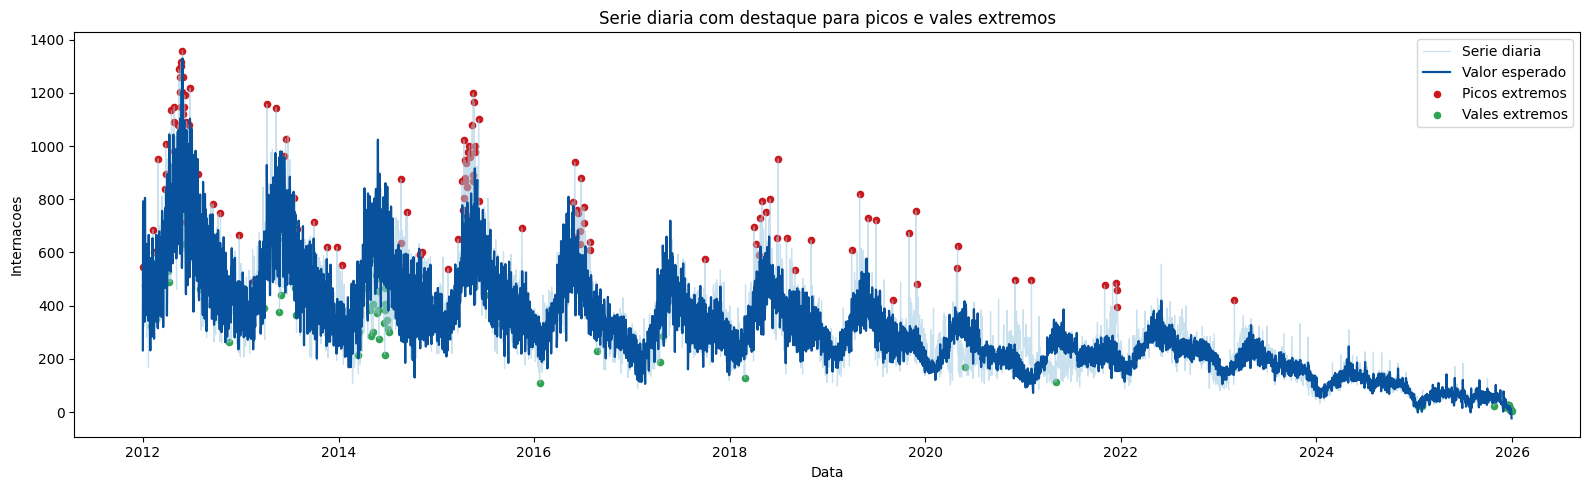

In [11]:
colunas_resumo_extremos = ["num_internacoes", "valor_esperado", "desvio_ajustado", "z_robusto"]

top_picos = (
    df_extremos.nlargest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_vales = (
    df_extremos.nsmallest(10, "num_internacoes")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_positivas = (
    df_extremos.nlargest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)
top_anomalias_negativas = (
    df_extremos.nsmallest(10, "desvio_ajustado")[colunas_resumo_extremos]
    .reset_index()
    .rename(columns={"index": "data_dia"})
)

display(top_picos.round(2))
display(top_vales.round(2))
display(top_anomalias_positivas.round(2))
display(top_anomalias_negativas.round(2))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(df_extremos.index, df_extremos["num_internacoes"], color="#9ecae1", linewidth=0.9, alpha=0.55, label="Serie diaria")
ax.plot(df_extremos.index, df_extremos["valor_esperado"], color="#08519c", linewidth=1.6, label="Valor esperado")
ax.scatter(
    df_extremos.index[df_extremos["pico_extremo"]],
    df_extremos.loc[df_extremos["pico_extremo"], "num_internacoes"],
    color="#cb181d",
    s=20,
    label="Picos extremos",
)
ax.scatter(
    df_extremos.index[df_extremos["vale_extremo"]],
    df_extremos.loc[df_extremos["vale_extremo"], "num_internacoes"],
    color="#31a354",
    s=20,
    label="Vales extremos",
)
ax.set_title("Serie diaria com destaque para picos e vales extremos")
ax.set_xlabel("Data")
ax.set_ylabel("Internacoes")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

### Frequencia e distribuicao dos extremos

Agora quantificamos quantos extremos existem ao longo de toda a serie e em quais anos e meses eles se concentram. Isso ajuda a responder se os eventos raros estao espalhados ao acaso ou se aparecem em certos regimes e janelas sazonais.

,tipo,quantidade,percentual_dias
0,Picos extremos,132,2.58
1,Vales extremos,90,1.76
2,Extremos totais,222,4.34


,ano,dias,picos_extremos,vales_extremos,total_extremos,taxa_extremos_pct
0,2012,366,38,15,53,14.48
2,2014,365,11,30,41,11.23
3,2015,365,27,3,30,8.22
13,2025,364,0,26,26,7.14
1,2013,365,13,8,21,5.75
4,2016,366,12,3,15,4.10
6,2018,365,12,1,13,3.56
7,2019,365,8,0,8,2.19
9,2021,365,5,1,6,1.64
5,2017,365,2,2,4,1.10


,mes_nome,picos_extremos,vales_extremos,total_extremos
0,Jan,3,9,12
1,Fev,6,2,8
2,Mar,6,3,9
3,Abr,23,11,34
4,Mai,31,18,49
5,Jun,21,11,32
6,Jul,11,9,20
7,Ago,5,3,8
8,Set,5,1,6
9,Out,6,3,9


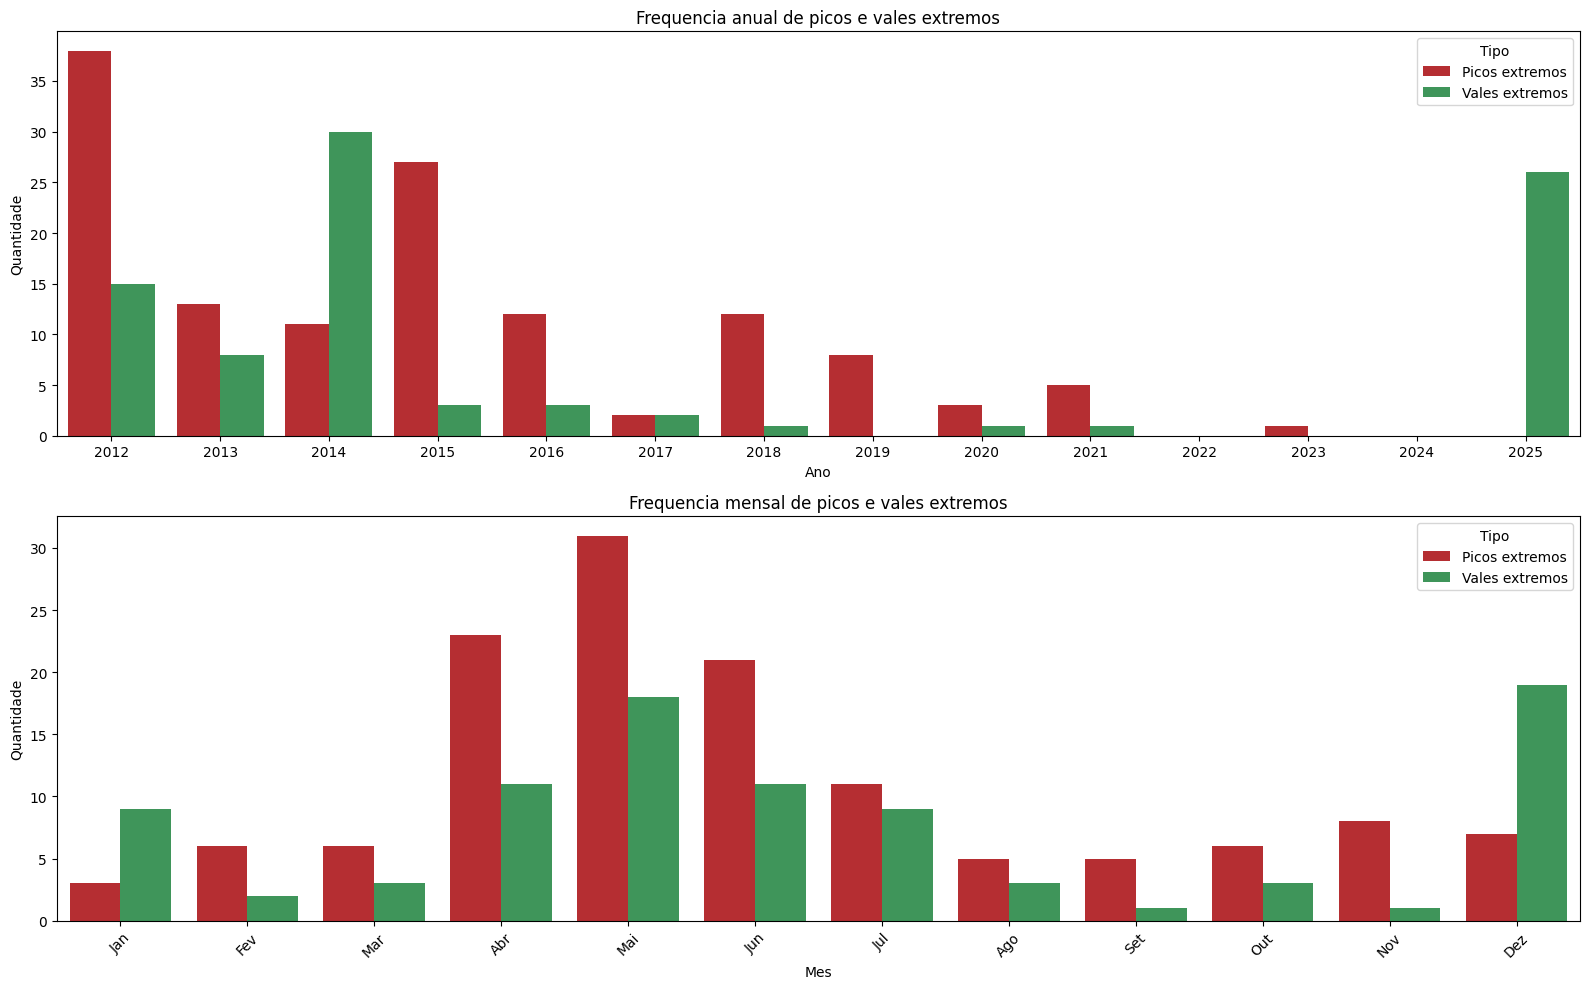

In [12]:
resumo_frequencia_extremos = pd.DataFrame(
    {
        "tipo": ["Picos extremos", "Vales extremos", "Extremos totais"],
        "quantidade": [
            int(df_extremos["pico_extremo"].sum()),
            int(df_extremos["vale_extremo"].sum()),
            int(df_extremos["extremo"].sum()),
        ],
    }
)
resumo_frequencia_extremos["percentual_dias"] = 100 * resumo_frequencia_extremos["quantidade"] / len(df_extremos)

frequencia_por_ano = (
    df_extremos.groupby("ano")
    .agg(
        dias=("num_internacoes", "size"),
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
)
frequencia_por_ano["taxa_extremos_pct"] = 100 * frequencia_por_ano["total_extremos"] / frequencia_por_ano["dias"]

frequencia_por_mes = (
    df_extremos.groupby(["mes", "mes_nome"], observed=True)
    .agg(
        picos_extremos=("pico_extremo", "sum"),
        vales_extremos=("vale_extremo", "sum"),
        total_extremos=("extremo", "sum"),
    )
    .reset_index()
    .sort_values("mes")
)

display(resumo_frequencia_extremos.round(2))
display(frequencia_por_ano.sort_values("total_extremos", ascending=False).head(10).round(2))
display(frequencia_por_mes[["mes_nome", "picos_extremos", "vales_extremos", "total_extremos"]].round(2))

freq_ano_long = frequencia_por_ano.melt(
    id_vars="ano",
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_ano_long["tipo"] = freq_ano_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

freq_mes_long = frequencia_por_mes.melt(
    id_vars=["mes", "mes_nome"],
    value_vars=["picos_extremos", "vales_extremos"],
    var_name="tipo",
    value_name="quantidade",
)
freq_mes_long["tipo"] = freq_mes_long["tipo"].map({"picos_extremos": "Picos extremos", "vales_extremos": "Vales extremos"})

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

sns.barplot(data=freq_ano_long, x="ano", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[0])
axes[0].set_title("Frequencia anual de picos e vales extremos")
axes[0].set_xlabel("Ano")
axes[0].set_ylabel("Quantidade")
axes[0].legend(title="Tipo", loc="upper right")

sns.barplot(data=freq_mes_long, x="mes_nome", y="quantidade", hue="tipo", palette=["#cb181d", "#31a354"], ax=axes[1])
axes[1].set_title("Frequencia mensal de picos e vales extremos")
axes[1].set_xlabel("Mes")
axes[1].set_ylabel("Quantidade")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(title="Tipo", loc="upper right")

plt.tight_layout()
plt.show()

### Inspecao de janelas em torno dos eventos raros

A tabela de extremos mostra *onde* olhar. Agora montamos janelas de contexto para ver *como* cada evento se comporta no entorno. Em saude, isso ajuda a distinguir um pico isolado, um vale administrativo ou um trecho que faz parte de uma onda mais longa.

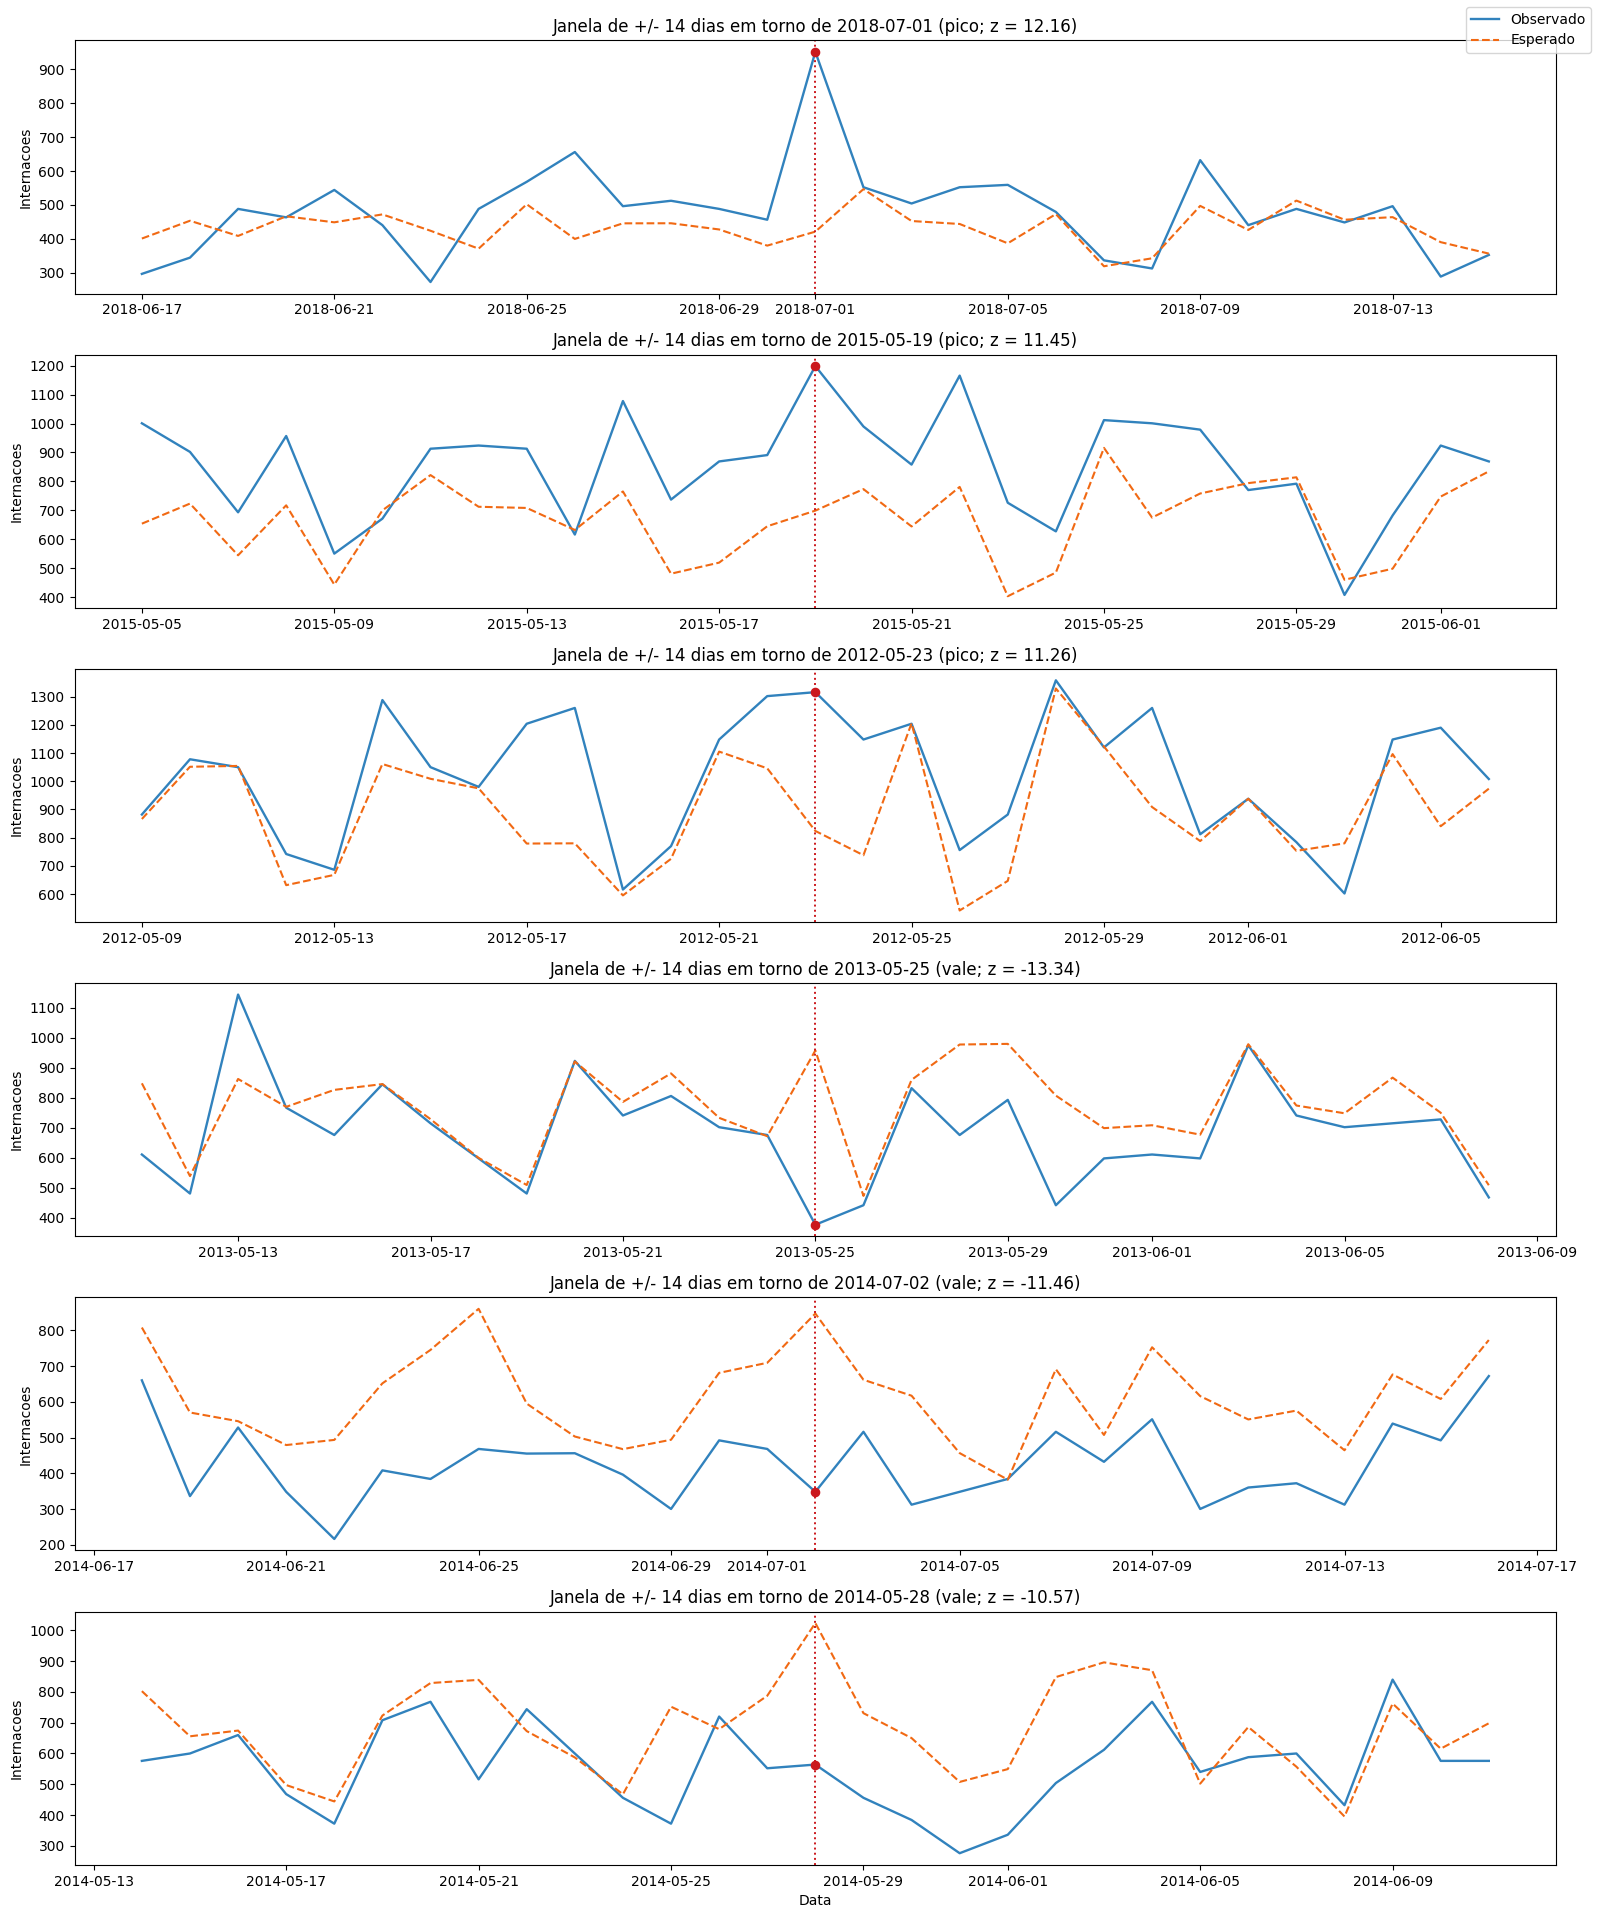

,data_evento,tipo_evento,valor_evento,valor_esperado,desvio_ajustado,z_robusto,media_janela,min_janela,max_janela
0,2018-07-01,Pico,952,420.78,531.22,12.16,479.34,272,952
1,2015-05-19,Pico,1199,698.77,500.23,11.45,852.31,407,1199
2,2012-05-23,Pico,1316,823.77,492.23,11.26,1020.07,602,1358
3,2013-05-25,Vale,377,957.75,-580.75,-13.34,684.97,377,1144
4,2014-07-02,Vale,348,847.03,-499.03,-11.46,426.52,216,672
5,2014-05-28,Vale,564,1023.81,-459.81,-10.57,557.38,276,840


In [13]:
def resumir_janelas_evento(df_base, datas_evento, dias_janela=14):
    resumos = []
    for data_evento in datas_evento:
        janela = df_base.loc[
            data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
        ].copy()
        if janela.empty:
            continue
        resumos.append(
            {
                "data_evento": data_evento,
                "tipo_evento": "Pico" if df_base.loc[data_evento, "desvio_ajustado"] >= 0 else "Vale",
                "valor_evento": df_base.loc[data_evento, "num_internacoes"],
                "valor_esperado": df_base.loc[data_evento, "valor_esperado"],
                "desvio_ajustado": df_base.loc[data_evento, "desvio_ajustado"],
                "z_robusto": df_base.loc[data_evento, "z_robusto"],
                "media_janela": janela["num_internacoes"].mean(),
                "min_janela": janela["num_internacoes"].min(),
                "max_janela": janela["num_internacoes"].max(),
            }
        )
    return pd.DataFrame(resumos)

# Selecionamos alguns eventos para inspecao detalhada combinando anomalias positivas e negativas.
datas_inspecao = list(
    dict.fromkeys(
        list(df_extremos.nlargest(3, "desvio_ajustado").index)
        + list(df_extremos.nsmallest(3, "desvio_ajustado").index)
    )
)

dias_janela = 14
fig, axes = plt.subplots(len(datas_inspecao), 1, figsize=(16, 3.2 * len(datas_inspecao)), sharex=False)
if len(datas_inspecao) == 1:
    axes = [axes]

for ax, data_evento in zip(axes, datas_inspecao):
    janela = df_extremos.loc[
        data_evento - pd.Timedelta(days=dias_janela): data_evento + pd.Timedelta(days=dias_janela)
    ].copy()
    ax.plot(janela.index, janela["num_internacoes"], color="#3182bd", linewidth=1.7, label="Observado")
    ax.plot(janela.index, janela["valor_esperado"], color="#f16913", linestyle="--", linewidth=1.5, label="Esperado")
    ax.axvline(data_evento, color="#cb181d", linestyle=":", linewidth=1.4)
    ax.scatter([data_evento], [df_extremos.loc[data_evento, "num_internacoes"]], color="#cb181d", s=35, zorder=3)
    tipo_evento = "pico" if df_extremos.loc[data_evento, "desvio_ajustado"] >= 0 else "vale"
    ax.set_title(
        f"Janela de +/- {dias_janela} dias em torno de {data_evento.date()} ({tipo_evento}; z = {df_extremos.loc[data_evento, 'z_robusto']:.2f})"
    )
    ax.set_ylabel("Internacoes")

axes[-1].set_xlabel("Data")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right")
plt.tight_layout()
plt.show()

display(resumir_janelas_evento(df_extremos, datas_inspecao, dias_janela=dias_janela).round(2))

### Resumo interpretativo dos resultados

A analise mostrou que os extremos da serie sao **assimetricos** e **nao estao espalhados ao acaso**. Na execucao desta etapa, foram identificados **222 dias extremos (4,34% da serie)**, com predominio de **picos extremos (132 dias; 2,58%)** sobre **vales extremos (90 dias; 1,76%)**. Isso sugere que os eventos raros aparecem mais como **ondas de alta** do que como quedas abruptas persistentes, embora a frequencia total de extremos tenha ficado bem menor do que na versao anterior da base.

Os **maiores picos brutos** ficaram fortemente concentrados em **maio-junho de 2012**, com destaque para **2012-05-28 (1358)**, **2012-05-23 (1316)** e **2012-05-22 (1302)**, alem de um pico importante em **2015-05-19 (1199)**. Mas a leitura por **anomalias ajustadas** refinou bastante essa interpretacao: o caso mais expressivo foi **2018-07-01**, com **952 internacoes** frente a um valor esperado de **420,8**, gerando desvio ajustado de **+531,2** e `z_robusto = 12,16`. Tambem se destacaram **2015-05-19 (+500,2)**, **2012-05-23 (+492,2)** e **2015-06-08 (+484,7)**. Isso mostra que nem todo pico bruto muito alto e necessariamente anomalo; por exemplo, **2012-05-28** foi o maior valor absoluto da serie, mas ficou muito proximo do esperado para aquele contexto.

Um contraste importante apareceu nos **vales**. Os menores valores brutos da serie ficaram concentrados no fim de **2025**, com registros entre **3** e **17 internacoes**, mas seus desvios ajustados ficaram proximos de zero. Isso indica que esses minimos recentes parecem refletir mais o **patamar estruturalmente baixo da serie no fim do periodo** do que uma anomalia rara. Ja os vales ajustados mais fortes ocorreram em **2013-05-25 (-580,8)**, **2014-07-02 (-499,0)** e **2014-05-28 (-459,8)**, datas em que a serie ficou muito abaixo do esperado em meses que costumam ser intensos. Isso sugere possiveis efeitos de **calendario, subregistro, mudanca operacional ou interrupcao temporaria de fluxo**, e nao necessariamente reducao real do risco epidemiologico.

A distribuicao temporal reforca esse diagnostico. O ano de **2012** concentrou **53 extremos** e taxa de aproximadamente **14,5%** dos dias, seguido por **2014 (41; 11,2%)** e **2015 (30; 8,2%)**. Em **2025**, apesar do patamar baixo, apareceram **26 extremos**, puxados principalmente por **vales** no fim do ano. No calendario anual, **abril, maio e junho** concentraram a maior parte dos extremos, especialmente os picos, com destaque para **maio (49 extremos, sendo 31 picos)**. Ja **dezembro** se destacou pelo aumento de **vales** (**19**), coerente com possiveis efeitos de feriados, fechamento de ano ou padrao operacional.

As **janelas locais** ajudam a interpretar a natureza desses eventos. Os principais picos positivos ocorreram dentro de janelas ja elevadas, com medias em torno de **479 a 1020 internacoes**, o que indica **ondas prolongadas**, e nao apenas pontos isolados. Em contraste, os vales negativos mais fortes aconteceram dentro de janelas ainda relativamente altas, com medias de **426 a 685 internacoes**, funcionando como **quedas localizadas em meio a periodos intensos**. Isso e importante porque mostra que nem todo extremo deve ser removido como outlier sem analise contextual.

**Possiveis analises e consequencias**
- Os grandes picos de **2012-2015**, e tambem os eventos ajustados de **2018-2019**, devem ser tratados como eventos substantivos da serie e cruzados com clima, poluicao, surtos virais, feriados e mudancas de oferta assistencial.
- A deteccao de anomalias ajustadas se mostrou mais informativa do que olhar apenas os valores brutos, porque separa melhor **patamar alto ou baixo esperado** de **evento raro de fato**.
- Para modelagem, vale usar abordagens robustas a outliers e incluir `dummies` de evento, feriado e regime, em vez de simplesmente excluir todos os extremos.
- Os vales de **dezembro** e os vales ajustados fortes de **2013-2014** merecem verificacao de qualidade do dado, porque podem refletir atraso de notificacao ou efeito administrativo.
- Como os extremos se concentram em janelas e anos especificos, a serie reforca a hipotese de **nao estacionariedade** e de **comportamento por regimes/ondas**.